In [1]:
import matplotlib
matplotlib.rcParams['font.serif'] = ['Times'] + matplotlib.rcParams['font.serif']
matplotlib.rcParams['font.size'] = 6
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams["ps.usedistiller"] = 'xpdf'
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.weight'] = 'normal'
matplotlib.rcParams["mathtext.fontset"] = 'cm'

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import random
import math

import pandas as pd

import copy

import cvxpy
cp = cvxpy

import figurefirst as fifi

from braid_analysis import braid_analysis_plots
from braid_analysis import flymath
import fly_plot_lib.plot as fpl

import pynumdiff

import scipy.stats

/home/caveman/PY38/lib/python3.8/site-packages/FlyPlotLib-0.0.1-py3.8.egg/fly_plot_lib/text.py:92: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/caveman/PY38/lib/python3.8/site-packages/FlyPlotLib-0.0.1-py3.8.egg/fly_plot_lib/text.py:94: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/caveman/PY38/lib/python3.8/site-packages/FlyPlotLib-0.0.1-py3.8.egg/fly_plot_lib/text.py:92: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/caveman/PY38/lib/python3.8/site-packages/FlyPlotLib-0.0.1-py3.8.egg/fly_plot_lib/text.py:94: SyntaxWarning: "is" with a literal. Did you mean "=="?


# Helper functions

In [ ]:
from splitflow.affine_math_and_plot_helper import *

# Hyper parameters

In [4]:
RANDOMNESS = True

# 
SPEED = 0.3
SPEED_STD = 0.1

UPWIND_TRANSLATION_MULTIPLIER = 0.1
UPWIND_TRANSLATION_MULTIPLIER_STD = 0.2

UPWIND_GAMMA_MULTIPLIER = 0.08
UPWIND_GAMMA_MULTIPLIER_STD = 0.02

SACCADE_THRESHOLD_PROPORTIONAL = 8
SACCADE_THRESHOLD_PROPORTIONAL_STD = 3
SACCADE_THRESHOLD_DERIVATIVE = 3
SACCADE_THRESHOLD_DERIVATIVE_STD = 1

SMOOTHING_WINDOW = 11
SMOOTHING_WINDOW_STD = 4

SLOPE = 3.95
SLOPE_STD = 0.3

SIGMOID_MIDPOINT = 0.1
SIGMOID_MIDPOINT_STD = 0.1

SIGMOID_STEEPNESS = 8
SIGMOID_STEEPNESS_STD = 2

COURSE_ANGLE_STD = 0.2

dt = 0.01
t, wind_direction, wind_speed = get_wind('laminar', RANDOMNESS, 11, dt)
LENGTH = len(t)

In [6]:
def get_smoothing_window():
    v = int(np.random.normal(SMOOTHING_WINDOW, SMOOTHING_WINDOW_STD))
    if v < 3:
        v = 3
    return v

def get_slope():
    s = np.random.normal(SLOPE, SLOPE_STD)
    noise = np.random.normal(0, 1, LENGTH)
    w = 10*get_smoothing_window()
    noise = pynumdiff.savgoldiff(noise, dt, [3,w,w])[0]
    
    return s + noise

def get_sigmoid_midpoint():
    m = np.random.normal(SIGMOID_MIDPOINT, SIGMOID_MIDPOINT_STD)
    if m<0.02:
        m = 0.02
    return m

def get_sigmoid_steepness():
    s = np.random.normal(SIGMOID_STEEPNESS, SIGMOID_STEEPNESS_STD)
    if s<2:
        s = 2
    return s

def get_speed():
    s = np.random.normal(SPEED, SPEED_STD, LENGTH)
    w = get_smoothing_window()
    s = pynumdiff.savgoldiff(s, dt, [3,w,w])[0]
    return s

def get_noisy_course(course_angle):
    noise = np.random.normal(0, COURSE_ANGLE_STD, LENGTH)
    w = get_smoothing_window()
    noise = pynumdiff.savgoldiff(noise, dt, [3,w,w])[0]
    course_angle = wrap_angle(course_angle + noise)
    return course_angle

def get_upwind_translation_multiplier():
    s = np.random.normal(UPWIND_TRANSLATION_MULTIPLIER, UPWIND_TRANSLATION_MULTIPLIER_STD)
    return s



In [20]:
scenario = 'laminar'

t, wind_direction, wind_speed = get_wind(scenario, RANDOMNESS, get_smoothing_window(), dt)
raw_circle_course = get_circle_basis(t, RANDOMNESS, get_slope())
axis_ratio = get_axis_ratio(wind_direction, wind_speed, get_sigmoid_midpoint(), get_sigmoid_steepness())
color = get_color(scenario)

/home/caveman/PY38/lib/python3.8/site-packages/pynumdiff/polynomial_fit/_polynomial_fit.py:132: UserWarning: Kernel window size should be odd. Added 1 to length.
  warn("Kernel window size should be odd. Added 1 to length.")


In [47]:
def get_pre_search_course(wind_direction, wind_magnitude, 
                          before_flash_frames=20, 
                          after_flash_delay_frames=10,
                          anemometric_turn_frames=10,
                          total_after_flash_frames=100,
                          dt=0.01,
                         ):
    initial_heading = np.random.uniform(-np.pi/2, np.pi/2)
    pre_trajec = [initial_heading]*(before_flash_frames+after_flash_delay_frames)
    anemometric_turn = np.random.uniform(-np.pi, np.pi)
    pre_trajec.extend([initial_heading+anemometric_turn]*10)

    num_surge_frames = total_after_flash_frames - anemometric_turn_frames - after_flash_delay_frames
    surge = wind_direction + np.pi

    # don't surge if wind magnitude is really low
    ix = np.where(wind_magnitude<0.03)[0]
    surge[ix] = pre_trajec[-1]

    surge = surge[0:num_surge_frames]
    
    pre_trajec = np.hstack((pre_trajec, surge))

    pre_trajec = wrap_angle(pre_trajec)

    t = np.arange(-before_flash_frames, total_after_flash_frames, 1)
    
    return t*dt, pre_trajec

In [48]:
t, angle = get_pre_search_course(wind_direction, wind_speed)

In [50]:
t[-1]

0.99

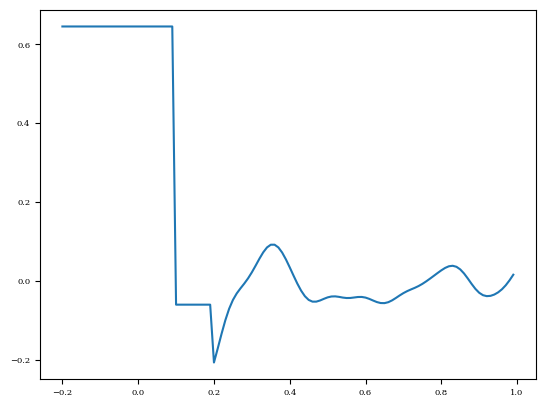

In [49]:
plt.plot(t, angle)

### Circle trajec and course

In [8]:
raw_circle_xy = get_circle_xy(raw_circle_course)
#circle_x, circle_y = get_trajec(get_noisy_course(raw_circle_course), dt, get_speed())

In [9]:
affine_trans_warped_course_angle, affine_trans_warped_circle_xy, mean_affine_trans_warped_circle_xy = get_affine_warped_course_angle(axis_ratio, 
                                                                                                                   wind_direction, 
                                                                                                                   raw_circle_xy,
                                                                                                                   translation_magnitude=get_upwind_translation_multiplier()
                                                                                                                   )
x, y = get_trajec(get_noisy_course(affine_trans_warped_course_angle), dt, get_speed())

In [10]:
staircase_warped_course_angle = get_upwind_biased_trajec_saccade(wind_direction, axis_ratio, affine_trans_warped_circle_xy, 
                                     dt,
                                     0,
                                     SMOOTHING_WINDOW, 
                                     SACCADE_THRESHOLD_PROPORTIONAL, SACCADE_THRESHOLD_DERIVATIVE,
                                     RANDOMNESS=False)
sac_x, sac_y = get_trajec(get_noisy_course(staircase_warped_course_angle), dt, get_speed())

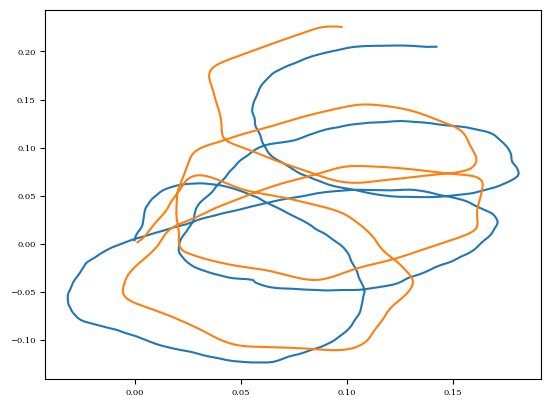

In [11]:
plt.plot(x,y)
plt.plot(sac_x, sac_y)


